# Предиктивное обслуживание электротранспорта — Разведочный анализ данных (EDA)

## Описание датасета

**Датасет:** NASA Li-ion Battery Aging Dataset

**Источники:** 
- https://www.kaggle.com/datasets/datasetengineer/eviot-predictivemaint-dataset
- https://data.nasa.gov/dataset/li-ion-battery-aging-datasets

Данный датасет данных был собран на специально созданном испытательном стенде для прогнозирования состояния батарей в Центре передового опыта в области прогнозирования NASA Ames (PCoE). Литий-ионные батареи тестировались в трех различных режимах работы (зарядка, разрядка и электрохимическая импедансная спектроскопия) при разных температурах. Разрядка проводилась при различных уровнях токовой нагрузки до тех пор, пока напряжение батареи не упало до заданных пороговых значений. Некоторые из этих пороговых значений были ниже рекомендованных производителем (2,7 В), чтобы вызвать эффекты старения при глубоком разряде. Повторные циклы зарядки и разрядки приводят к ускоренному старению батарей. Эксперименты были остановлены, когда батареи достигли критерия окончания срока службы (EOL) — снижения номинальной емкости на 30%.

---

### **Назначение ноутбука**

Этот ноутбук выполняет **разведочный анализ данных (EDA)** и **очистку** датасета NASA Li-ion Battery Aging Dataset. Результат — очищенный датасет `final_df_clean` — сохраняется в `/battery_dataset/final_df_clean.csv` и используется как **единый источник данных** для двух последующих ноутбуков:

1. **`battery.ipynb`** — базовое моделирование: прогноз емкости текущего цикла (Random Forest, LSTM).
2. **`battery_enhanced.ipynb`** — продвинутое моделирование: прогноз SOH и RUL, multi-task LSTM, система предупреждений.

Такое разделение гарантирует, что оба ноутбука работают на одном и том же очищенном датасете, что обеспечивает воспроизводимость и корректное сравнение моделей.


## **Часть 1. Загрузка, парсинг и EDA**

Загружаем .mat-файлы NASA, проводим системный разведочный анализ по 8 направлениям, очищаем данные и сохраняем результат для последующих моделей.

### **Блок 1: Импорт библиотек и настройка путей**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import re
import warnings
import scipy
from scipy import stats
from scipy.io import loadmat
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Игнорируем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# Настройка стиля графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Для красивого вывода таблиц
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


In [2]:
# --- НАСТРОЙКА ПУТИ ---
# Укажите путь к корневой папке. 
# Если вы в Colab, раскомментируйте строки ниже и настройте путь к Google Drive:

# from google.colab import drive
# drive.mount('/content/drive')
# ROOT_DIR = '/content/drive/My Drive/battery_dataset' 

# Если работаете локально, просто укажите имя папки (если ноутбук рядом с ней):
ROOT_DIR = r'D:\Education\Магистратура\Проектный семинар - диплом\Данные для диплома\NASA_Battery\battery_dataset' 

print(f"Корневая директория: {ROOT_DIR}")
print(f"Папка существует: {os.path.exists(ROOT_DIR)}")

Корневая директория: D:\Education\Магистратура\Проектный семинар - диплом\Данные для диплома\NASA_Battery\battery_dataset
Папка существует: True


### Блок 1.1. Посмотрим отдельно, какая информация содержится в каждом *.mat файле (на примере батареи B0025.mat)

In [3]:
import scipy.io
import numpy as np
import pandas as pd

# 1. Загрузка файла
path = r'D:\Education\Магистратура\Проектный семинар - диплом\Данные для диплома\NASA_Battery\battery_dataset\BatteryAgingARC_25-44\B0025.mat'
b0025 = scipy.io.loadmat(path)

# 2. Смотрим ключи верхнего уровня (настоящие, без служебных __)
keys = [k for k in b0025.keys() if not k.startswith('__')]
print("Ключи верхнего уровня:", keys)
# Ожидается: ['B0025']

# 3. Получаем структуру батареи
battery_id = keys[0]                     # 'B0025'
battery_struct = b0025[battery_id][0, 0] # распаковываем (1,1)-массив структур
print("\nПоля структуры батареи:", battery_struct.dtype.names)
# Ожидается: ('cycle',) — только циклы

# 4. Массив циклов
raw_cycles = battery_struct['cycle']
print(f"\nФорма массива cycles: {raw_cycles.shape}")  # (1, N)
print(f"Поля одного цикла:", raw_cycles.dtype.names)
# Ожидается: ('type', 'ambient_temperature', 'time', 'data')

# 5. Сводка по типам циклов (charge / discharge / impedance)
types = []
for i in range(raw_cycles.shape[1]):
    t = raw_cycles[0, i]['type'][0]
    if isinstance(t, bytes):
        t = t.decode('utf-8')
    types.append(t)
type_counts = pd.Series(types).value_counts()
print("\nЧисло циклов по типам операций:")
print(type_counts)

Ключи верхнего уровня: ['B0025']

Поля структуры батареи: ('cycle',)

Форма массива cycles: (1, 80)
Поля одного цикла: ('type', 'ambient_temperature', 'time', 'data')

Число циклов по типам операций:
charge       31
discharge    28
impedance    21
Name: count, dtype: int64


In [4]:
# Извлекаем только разрядные циклы -> DataFrame [battery_id, cycle, type, capacity]
rows = []
for i in range(raw_cycles.shape[1]):
    c = raw_cycles[0, i]
    t = c['type'][0]
    if isinstance(t, bytes):
        t = t.decode('utf-8')
    if t == 'discharge':
        meas = c['data'][0, 0]              # структура измерений
        cap = meas['Capacity'][0, 0]        # скаляр ёмкости (Ач)
        if isinstance(cap, np.ndarray):
            cap = cap.item()
        rows.append({
            'battery_id': battery_id,
            'cycle': i + 1,                 # нумерация с 1
            'type': t,
            'capacity': cap,
            'ambient_temperature': float(c['ambient_temperature'][0][0]),
        })

df_discharge = pd.DataFrame(rows)
print(f"\nЦиклов разряда: {len(df_discharge)}")
print("\nПервые 10 строк:")
display(df_discharge.head(10))

print("\nОписательная статистика:")
display(df_discharge.describe())


Циклов разряда: 28

Первые 10 строк:


,battery_id,cycle,type,capacity,ambient_temperature
0,B0025,4,discharge,1.847011,24.0
1,B0025,6,discharge,1.848565,24.0
2,B0025,8,discharge,1.847111,24.0
3,B0025,10,discharge,1.848984,24.0
4,B0025,12,discharge,1.837012,24.0
5,B0025,16,discharge,1.817549,24.0
6,B0025,20,discharge,1.839864,24.0
7,B0025,23,discharge,1.843060,24.0
8,B0025,25,discharge,1.840187,24.0
9,B0025,27,discharge,1.828127,24.0



Описательная статистика:


,cycle,capacity,ambient_temperature
count,28.000000,28.000000,28.0
mean,40.250000,1.816511,24.0
std,22.885585,0.022290,0.0
min,4.000000,1.767789,24.0
25%,22.250000,1.799435,24.0
50%,40.000000,1.815056,24.0
75%,57.500000,1.837725,24.0
max,78.000000,1.848984,24.0


Поля данных цикла разряда: ('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')

Измерений в цикле 4: 641 (точек во времени)


,time_s,voltage_V,current_A,temperature_C,current_load_A,voltage_load_V
0,0.000,4.196831,0.000296,26.515141,0.0004,0.000
1,9.360,4.196965,-0.000389,26.503791,0.0004,4.212
2,19.547,3.728471,-4.025041,26.585473,3.9960,1.806
3,29.500,4.166103,-0.002078,26.760213,0.0004,4.168
4,39.469,3.700860,-4.025402,26.888811,3.9960,1.792
5,49.375,4.147486,0.000545,27.064287,0.0004,4.146
6,59.407,3.679869,-4.026142,27.193330,3.9960,1.774
7,69.375,4.132850,0.001052,27.356509,0.0004,4.129
8,79.344,3.663663,-4.025619,27.471071,3.9960,1.762
9,89.375,4.120951,-0.001347,27.634189,0.0004,4.116


,time_s,voltage_V,current_A,temperature_C,current_load_A,voltage_load_V
count,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000
mean,3223.203808,3.400081,-1.068026,33.132820,1.060074,1.373816
std,1884.467058,0.277259,1.777769,4.256135,1.765217,1.549886
min,0.000000,1.918268,-4.027931,26.503791,0.000200,0.000000
25%,1595.657000,3.256414,-4.023974,28.823290,0.000400,0.000000
50%,3192.329000,3.287421,-0.001344,33.496537,0.000400,1.262000
75%,4850.204000,3.586894,-0.000324,36.664069,3.996000,3.410000
max,6515.422000,4.196965,0.003622,41.817481,3.996000,4.212000


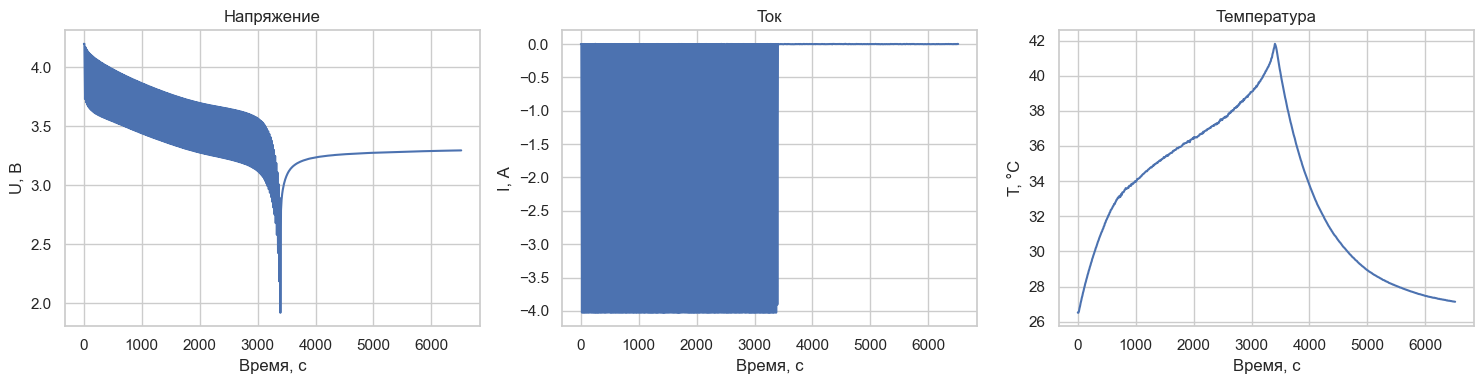

In [5]:
# Выберем первый разрядный цикл и покажем его измерения как таблицу
cycle_idx = df_discharge['cycle'].iloc[0] - 1   # индекс в массиве cycles
meas = raw_cycles[0, cycle_idx]['data'][0, 0]

print("Поля данных цикла разряда:", meas.dtype.names)
# ('Voltage_measured', 'Current_measured', 'Temperature_measured',
#  'Current_load', 'Voltage_load', 'Time', 'Capacity')

# Собираем DataFrame временного ряда одного цикла
cycle_ts = pd.DataFrame({
    'time_s':           meas['Time'].flatten(),
    'voltage_V':        meas['Voltage_measured'].flatten(),
    'current_A':        meas['Current_measured'].flatten(),
    'temperature_C':    meas['Temperature_measured'].flatten(),
    'current_load_A':   meas['Current_load'].flatten(),
    'voltage_load_V':   meas['Voltage_load'].flatten(),
})
print(f"\nИзмерений в цикле {cycle_idx+1}: {len(cycle_ts)} (точек во времени)")
display(cycle_ts.head(15))
display(cycle_ts.describe())

# Быстрый график разряда
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(cycle_ts['time_s'], cycle_ts['voltage_V']);  axes[0].set_title('Напряжение'); axes[0].set_xlabel('Время, с'); axes[0].set_ylabel('U, В')
axes[1].plot(cycle_ts['time_s'], cycle_ts['current_A']);  axes[1].set_title('Ток');        axes[1].set_xlabel('Время, с'); axes[1].set_ylabel('I, А')
axes[2].plot(cycle_ts['time_s'], cycle_ts['temperature_C']); axes[2].set_title('Температура'); axes[2].set_xlabel('Время, с'); axes[2].set_ylabel('T, °C')
plt.tight_layout(); plt.show()

### В целом, видно, что информации в исходном датасете достаточно много, но в этом исследовании мы остановимся только на отдельных ее составляющих.

### **Блок 2: Функция для парсинга одного .mat файла**

Файлы NASA содержат информацию о циклах. Самый важный показатель — емкость (Capacity) при разрядке. Именно падение емкости говорит о старении батареи. Мы будем извлекать только разрядные циклы ('discharge'), так как они показывают реальное состояние здоровья (SOH).

In [6]:
def parse_battery_file_universal(file_path, battery_id):
    try:
        mat = scipy.io.loadmat(file_path)
    except Exception as e:
        print(f"Ошибка чтения {file_path}: {e}")
        return pd.DataFrame()

    # 1. Получаем главный ключ (B0005)
    keys = [k for k in mat.keys() if not k.startswith('__')]
    if not keys:
        return pd.DataFrame()
    main_key = keys[0]
    
    # 2. Получаем структуру батареи
    battery_struct = mat[main_key][0, 0]
    
    # 3. Извлекаем массив циклов (Универсальный метод)
    raw_cycles = battery_struct['cycle']
    
    # Логика разворачивания:
    cycles = None
    
    if raw_cycles.ndim == 0:
        # Если это скаляр (0-d), достаем содержимое через .item()
        cycles = raw_cycles.item()
    elif raw_cycles.shape == (1, 1):
        # Если это массив 1x1, достаем единственный элемент
        cycles = raw_cycles[0, 0]
    else:
        # Если это уже массив с данными (например, (1, N)), оставляем как есть
        cycles = raw_cycles
        
    print(f"Файл {battery_id}: итоговая форма cycles: {cycles.shape}")

    # Теперь cycles должен быть массивом структур (1, N) или (N,)
    data_list = []
    
    # Определяем, как итерироваться
    # Стандарт NASA обычно (1, N)
    if cycles.ndim == 2:
        num_cycles = cycles.shape[1]
        iter_func = lambda i: cycles[0, i]
    elif cycles.ndim == 1:
        num_cycles = cycles.shape[0]
        iter_func = lambda i: cycles[i]
    else:
        # Если все еще скаляр (внутри лежит 1 цикл?), пробуем достать
        print(f"Внимание: cycles имеет странную форму {cycles.shape}, пропускаем.")
        return pd.DataFrame()

    for i in range(num_cycles):
        try:
            cycle_struct = iter_func(i)
            
            # Тип операции
            c_type_raw = cycle_struct['type'][0]
            if isinstance(c_type_raw, bytes):
                c_type = c_type_raw.decode('utf-8')
            else:
                c_type = str(c_type_raw)
            
            if c_type == 'discharge':
                # Данные измерений
                meas = cycle_struct['data'][0, 0]
                
                # Проверяем наличие Capacity
                if 'Capacity' in meas.dtype.names:
                    # Емкость может быть числом или массивом
                    cap_val = meas['Capacity'][0, 0]
                    if isinstance(cap_val, np.ndarray):
                        cap_val = cap_val.item()
                        
                    data_list.append({
                        'battery_id': battery_id,
                        'cycle': i + 1,
                        'type': c_type,
                        'capacity': cap_val
                    })
        except Exception as inner_e:
            # Если цикл поврежден, пропускаем его, но не ломаем весь скрипт
            continue
            
    print(f"  Извлечено записей: {len(data_list)}")
    return pd.DataFrame(data_list)

### **Блок 3: Загрузка всех файлов и объединение в один датасет**

Пройдемся по всем подпапкам, найдем файлы .mat и применим функцию из Блока 2.

In [7]:
# ЗАПУСК ОБРАБОТКИ ВСЕХ ФАЙЛОВ

ROOT_DIR = 'battery_dataset'
all_dfs = []

for root, dirs, files in os.walk(ROOT_DIR):
    for file in files:
        if file.endswith('.mat'):
            f_path = os.path.join(root, file)
            b_id = file.split('.')[0]
            
            df = parse_battery_file_universal(f_path, b_id)
            if not df.empty:
                all_dfs.append(df)

if all_dfs:
    final_df = pd.concat(all_dfs, ignore_index=True)
    print("\n=== УСПЕХ ===")
    print(final_df.head())
    print(final_df['battery_id'].value_counts())
else:
    print("Не удалось извлечь данные.")

Файл B0005: итоговая форма cycles: (1, 616)
  Извлечено записей: 168
Файл B0006: итоговая форма cycles: (1, 616)
  Извлечено записей: 168
Файл B0007: итоговая форма cycles: (1, 616)
  Извлечено записей: 168
Файл B0018: итоговая форма cycles: (1, 319)
  Извлечено записей: 132
Файл B0025: итоговая форма cycles: (1, 80)
  Извлечено записей: 28
Файл B0026: итоговая форма cycles: (1, 80)
  Извлечено записей: 28
Файл B0027: итоговая форма cycles: (1, 80)
  Извлечено записей: 28
Файл B0028: итоговая форма cycles: (1, 80)
  Извлечено записей: 28
Файл B0029: итоговая форма cycles: (1, 97)
  Извлечено записей: 40
Файл B0030: итоговая форма cycles: (1, 97)
  Извлечено записей: 40
Файл B0031: итоговая форма cycles: (1, 97)
  Извлечено записей: 40
Файл B0032: итоговая форма cycles: (1, 97)
  Извлечено записей: 40
Файл B0033: итоговая форма cycles: (1, 486)
  Извлечено записей: 197
Файл B0034: итоговая форма cycles: (1, 486)
  Извлечено записей: 197
Файл B0036: итоговая форма cycles: (1, 486)
  Извл

Размерность массива циклов — (1, N), где N варьирует от 80 до 616 в зависимости от батареи.

Емкость (capacity) находится в физически обоснованных пределах: начальная — от ~1.1 Ач (B0045, B0053) до ~2.0 Ач (B0005–B0007), минимальная в конце жизни — около 0.7–0.8 Ач.

Всего загружено 34 батареи (B0005–B0056) с числом циклов разряда от 4 (B0052) до 197 (B0033/B0034/B0036).

In [8]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2769 entries, 0 to 2768
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   battery_id  2769 non-null   str    
 1   cycle       2769 non-null   int64  
 2   type        2769 non-null   str    
 3   capacity    2769 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 124.5 KB


In [9]:
# Вывод первых 5 строк общего датасета
print("Первые 5 строк объединенного датасета:")
display(final_df.head())

# Вывод общей информации
print("\nОбщая информация о датасете:")
print(f"Всего записей (циклов разряда): {final_df.shape[0]}")
print(f"Количество уникальных батарей: {final_df['battery_id'].nunique()}")

Первые 5 строк объединенного датасета:


,battery_id,cycle,type,capacity
0,B0005,2,discharge,1.856487
1,B0005,4,discharge,1.846327
2,B0005,6,discharge,1.835349
3,B0005,8,discharge,1.835263
4,B0005,10,discharge,1.834646



Общая информация о датасете:
Всего записей (циклов разряда): 2769
Количество уникальных батарей: 34


In [10]:
final_df.describe()

,cycle,capacity
count,2769.000000,2769.000000
mean,165.124594,1.326543
std,143.529458,0.472517
min,1.000000,0.000000
25%,53.000000,1.150286
50%,121.000000,1.428065
75%,239.000000,1.673645
max,614.000000,2.640149


### **Блок 4: Расширенный разведочный анализ данных (EDA)**

Прежде чем переходить к моделированию, проведем системный EDA по 8 ключевым направлениям. Сначала добавим в `final_df` производный признак **SOH (State of Health)** — относительное состояние здоровья батареи: 

$$SOH = \frac{C_{current}}{C_{max}}$$

где $C_{current}$ — текущая измеренная емкость, $C_{max}$ — максимальная (начальная) емкость данной батареи. SOH=1.0 соответствует новой батарее, SOH≈0.7 — достижению критерия окончания срока службы (EOL, потеря 30% номинальной емкости по методике NASA).



In [11]:
# Добавляем SOH в final_df (нормировка на максимум емкости внутри каждой батареи)
soh_parts = []
for batt_id in final_df['battery_id'].unique():
    sub = final_df[final_df['battery_id'] == batt_id].copy().sort_values('cycle')
    max_cap = sub['capacity'].max()
    sub['soh'] = sub['capacity'] / max_cap
    soh_parts.append(sub)
final_df = pd.concat(soh_parts, ignore_index=True)

# Числовые и категориальные признаки
numeric_cols = ['cycle', 'capacity', 'soh']
categorical_cols = ['battery_id', 'type']

print(f"Числовые признаки: {numeric_cols}")
print(f"Категориальные признаки: {categorical_cols}")
print(f"Размерность: {final_df.shape}")
final_df[numeric_cols].describe().T


Числовые признаки: ['cycle', 'capacity', 'soh']
Категориальные признаки: ['battery_id', 'type']
Размерность: (2769, 5)


,count,mean,std,min,25%,50%,75%,max
cycle,2769.0,165.124594,143.529458,1.0,53.000000,121.000000,239.000000,614.000000
capacity,2769.0,1.326543,0.472517,0.0,1.150286,1.428065,1.673645,2.640149
soh,2769.0,0.749690,0.243767,0.0,0.711215,0.794065,0.907353,1.000000


#### **4.1. Распределения числовых признаков**

Строим гистограммы с KDE (ядерной оценкой плотности) для всех числовых признаков, а также считаем коэффициенты асимметрии (skew) и эксцесса (kurt). Это позволяет понять форму распределений и выбрать корректные преобразования/модели.


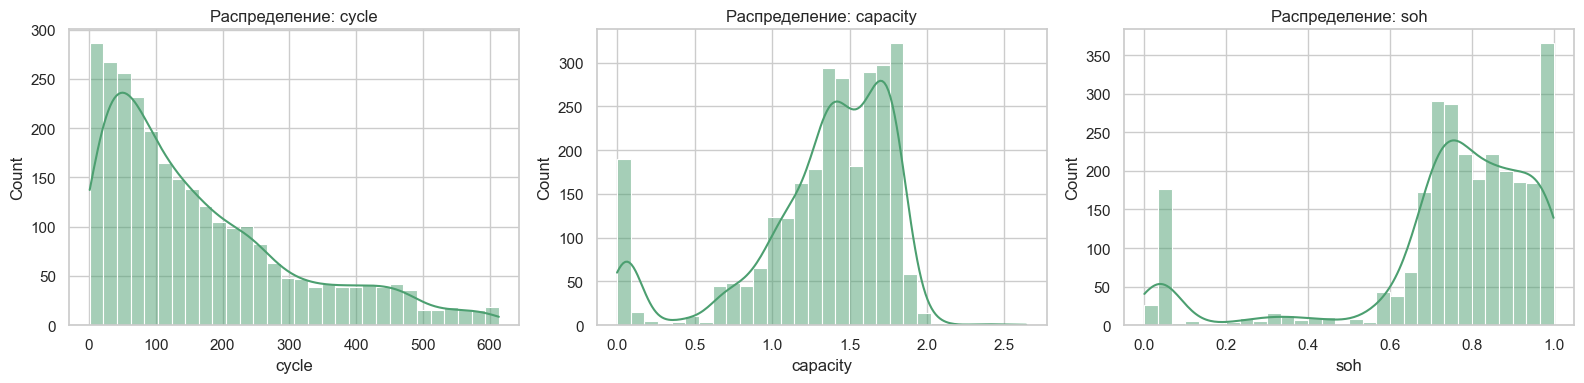

,mean,std,min,max,skew,kurt
cycle,165.124594,143.529458,1.0,614.000000,1.104113,0.460647
capacity,1.326543,0.472517,0.0,2.640149,-1.349371,1.432646
soh,0.749690,0.243767,0.0,1.000000,-1.852564,2.990405


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(final_df[col].dropna(), kde=True, ax=ax, color='#4C9F70', bins=30)
    ax.set_title(f'Распределение: {col}', fontsize=12)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

# Сводная таблица моментов распределения
moments = pd.DataFrame({
    'mean':   final_df[numeric_cols].mean(),
    'std':    final_df[numeric_cols].std(),
    'min':    final_df[numeric_cols].min(),
    'max':    final_df[numeric_cols].max(),
    'skew':   final_df[numeric_cols].skew(),
    'kurt':   final_df[numeric_cols].kurt(),
})
display(moments)


In [13]:
# Таблица моментов распределения (mean/std/skew/kurt) по каждой батарее:

# Сводная таблица моментов распределения для каждой батареи
moments_by_battery = (
    final_df
    .groupby('battery_id')[numeric_cols]
    .agg(['mean', 'std', 'skew'])
    .round(3)
)
# Превратим multi-index колонок в плоские имена вида "capacity_mean"
moments_by_battery.columns = ['_'.join(col).strip() for col in moments_by_battery.columns.values]
print("Моменты распределения по батареям (mean / std / skew):")
display(moments_by_battery)

Моменты распределения по батареям (mean / std / skew):


,cycle_mean,cycle_std,cycle_skew,capacity_mean,capacity_std,capacity_skew,soh_mean,soh_std,soh_skew
battery_id,,,,,,,,,
B0005,294.000,184.947,0.043,1.573,0.190,0.048,0.847,0.103,0.048
B0006,294.000,184.947,0.043,1.547,0.252,0.371,0.760,0.124,0.371
B0007,294.000,184.947,0.043,1.644,0.161,0.145,0.870,0.085,0.145
B0018,164.280,91.020,-0.023,1.558,0.155,0.309,0.840,0.083,0.309
B0025,40.250,22.886,0.003,1.817,0.022,-0.137,0.982,0.012,-0.137
B0026,40.250,22.886,0.003,1.776,0.082,-4.322,0.978,0.045,-4.322
B0027,40.250,22.886,0.003,1.805,0.013,-0.969,0.990,0.007,-0.969
B0028,40.250,22.886,0.003,1.770,0.023,-0.437,0.981,0.013,-0.437
B0029,48.000,27.993,-0.000,1.726,0.064,0.008,0.936,0.035,0.008


**Выводы по блоку 4.1:**

- **`cycle`** — распределение зависит от того, сколько циклов проработала каждая батарея; в полном датасете NASA (B0005–B0056, 34 батареи) число циклов разряда варьирует от 4 (B0052) до 197 (B0033/B0034/B0036). На объединенном датасете skew ≈ 1.1 (правая асимметрия), однако **внутри каждой отдельной батареи skew cycle ≈ 0** (см. таблицу выше) — циклы распределены равномерно, асимметрия возникает только за счет объединения батарей с разной длиной.
- **`capacity`** — распределение сосредоточено в диапазоне 0.7–1.7 Ач (mean ≈ 1.33), с длинным правым хвостом до ~2.6 Ач. Этот хвост соответствует **выбросам-пикам** в начальных циклах некоторых батарей (B0036, B0049/B0050/B0051), которые физически нереалистичны и подлежат сглаживанию в Блоке 5. По таблице моментов видны **аномальные skew по capacity внутри батарей**: B0053 (skew ≈ −6.6), B0048 (−3.7), B0046 (−3.3), B0047 (−3.3), B0045 (−2.7), B0033 (−3.0) — резкая левая асимметрия из-за провала емкости в конце жизни; у B0049/B0051 skew ≈ +1.7/+1.9 — правая асимметрия из-за пиков в начале.
- **`soh`** — имеет сильную левую асимметрию на объединенном датасете (skew ≈ −1.85): концентрируется в диапазоне 0.7–0.9, но с тяжелым хвостом к 0. Среднее SOH ≈ 0.75, что отражает значительную долю циклов с выраженной деградацией. **B0041 выделяется**: soh_mean ≈ 0.32, capacity_mean ≈ 0.39 — это глубоко деградировавшая батарея (не ошибка, а реальное состояние). Минимальное SOH≈0 соответствует аномальным нулевым измерениям емкости (см. 4.8) и подлежит обработке.

Распределения не имеют аномальной тяжелохвостости, требующей преобразований (log/Box-Cox). Регрессию на `capacity` можно проводить в исходной шкале.

#### **4.2. Выбросы (box plots)**

Для каждого числового признака строим box plot и считаем количество выбросов по правилу 1.5×IQR (межквартильный размах). Также строим box plot емкости по каждой батарее, чтобы увидеть неоднородность старения.


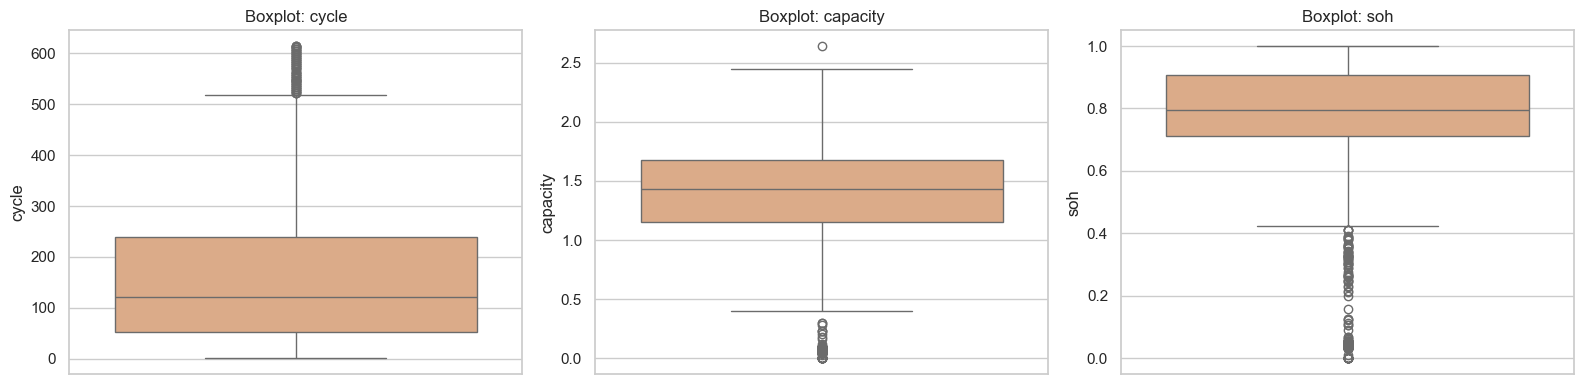

,feature,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers
0,cycle,53.000000,239.000000,186.000000,-226.000000,518.000000,75
1,capacity,1.150286,1.673645,0.523359,0.365247,2.458684,214
2,soh,0.711215,0.907353,0.196138,0.417008,1.201560,273


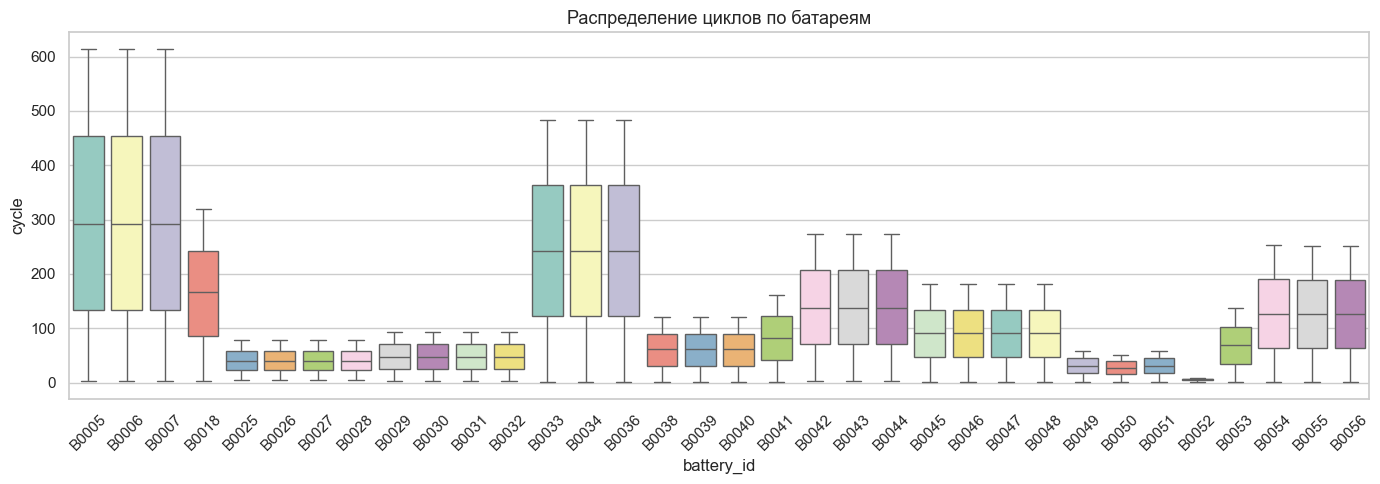

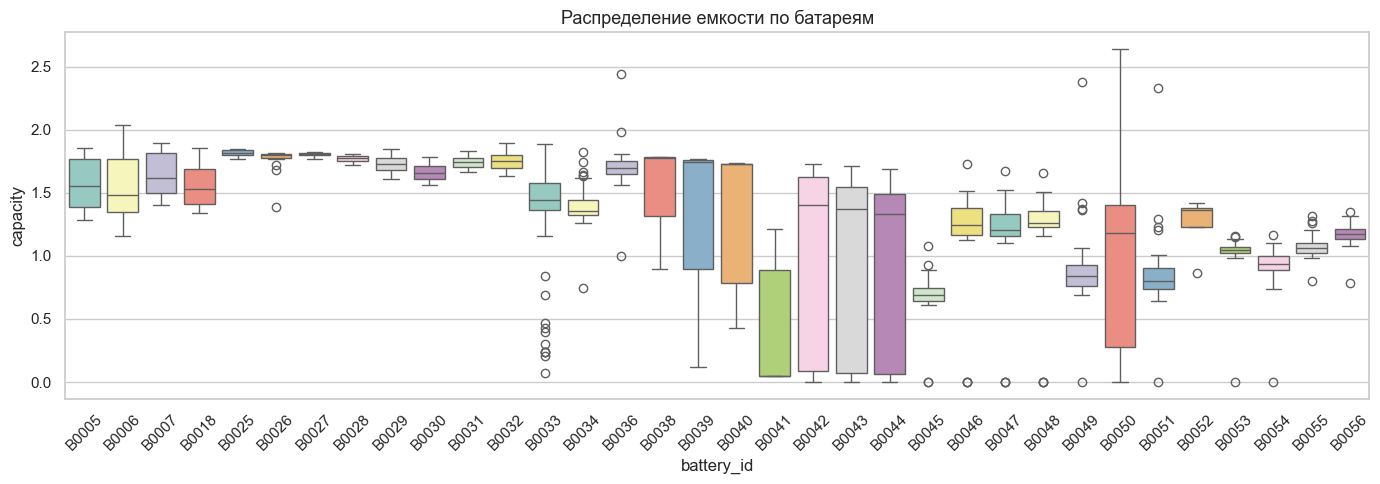

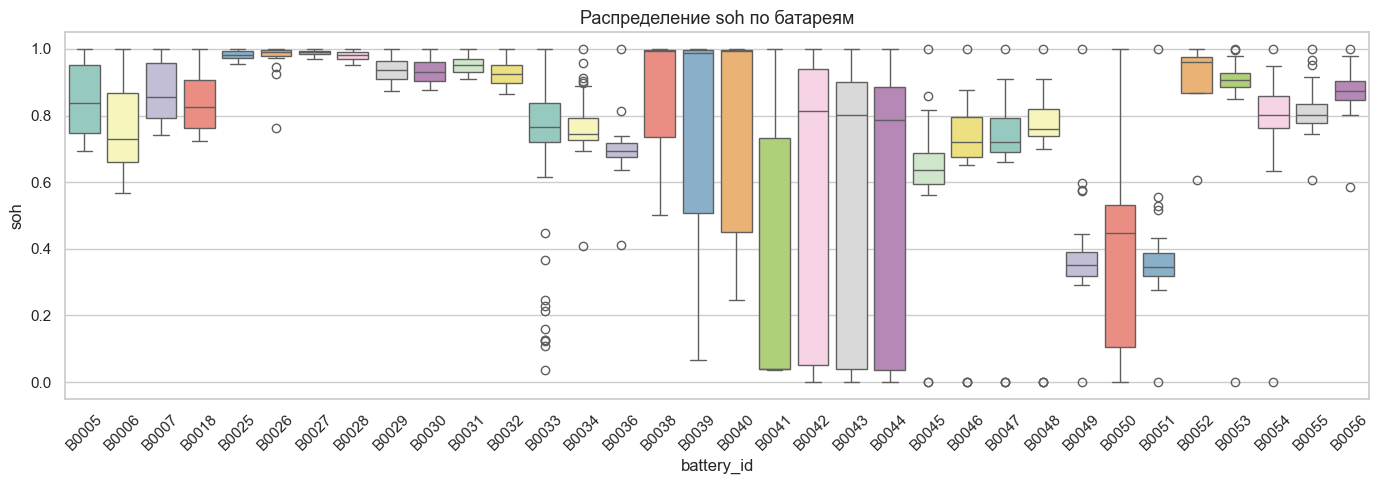

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
outlier_stats = []
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=final_df[col], ax=ax, color='#E8A87C')
    ax.set_title(f'Boxplot: {col}', fontsize=12)
    q1, q3 = final_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((final_df[col] < lo) | (final_df[col] > hi)).sum()
    outlier_stats.append({'feature': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                          'lower_fence': lo, 'upper_fence': hi, 'n_outliers': n_out})
plt.tight_layout()
plt.show()

display(pd.DataFrame(outlier_stats))

# Boxplot циклов по всем батареям
plt.figure(figsize=(14, 5))
sns.boxplot(data=final_df, x='battery_id', y='cycle', palette='Set3')
plt.xticks(rotation=45)
plt.title('Распределение циклов по батареям', fontsize=13)
plt.tight_layout()
plt.show()

# Boxplot емкости по всем батареям
plt.figure(figsize=(14, 5))
sns.boxplot(data=final_df, x='battery_id', y='capacity', palette='Set3')
plt.xticks(rotation=45)
plt.title('Распределение емкости по батареям', fontsize=13)
plt.tight_layout()
plt.show()

# Boxplot soh по всем батареям
plt.figure(figsize=(14, 5))
sns.boxplot(data=final_df, x='battery_id', y='soh', palette='Set3')
plt.xticks(rotation=45)
plt.title('Распределение soh по батареям', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Сводная таблица выбросов (1.5×IQR) по каждой батарее
outlier_rows = []
for bid in final_df['battery_id'].unique():
    sub = final_df[final_df['battery_id'] == bid]
    for col in numeric_cols:
        q1, q3 = sub[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = int(((sub[col] < lo) | (sub[col] > hi)).sum())
        outlier_rows.append({
            'battery_id': bid,
            'feature': col,
            'n': len(sub),
            'min': round(sub[col].min(), 3),
            'Q1': round(q1, 3),
            'Q3': round(q3, 3),
            'IQR': round(iqr, 3),
            'max': round(sub[col].max(), 3),
            'n_outliers': n_out,
            'pct_outliers': round(n_out / len(sub) * 100, 2),
        })
outliers_by_battery = pd.DataFrame(outlier_rows)

# Покажем отдельно по каждому признаку
print("Выбросы (правило 1.5×IQR) по батареям — признак: capacity")
display(outliers_by_battery[outliers_by_battery['feature'] == 'capacity']
        .sort_values('n_outliers', ascending=False)
        .reset_index(drop=True))

print("\nВыбросы (правило 1.5×IQR) по батареям — признак: soh")
display(outliers_by_battery[outliers_by_battery['feature'] == 'soh']
        .sort_values('n_outliers', ascending=False)
        .reset_index(drop=True))

print("\nВыбросы (правило 1.5×IQR) по батареям — признак: cycle")
display(outliers_by_battery[outliers_by_battery['feature'] == 'cycle']
        .sort_values('n_outliers', ascending=False)
        .reset_index(drop=True))

Выбросы (правило 1.5×IQR) по батареям — признак: capacity


,battery_id,feature,n,min,Q1,Q3,IQR,max,n_outliers,pct_outliers
0,B0033,capacity,197,0.068,1.360,1.581,0.221,1.885,11,5.58
1,B0034,capacity,197,0.746,1.325,1.444,0.119,1.820,6,3.05
2,B0049,capacity,25,0.000,0.759,0.930,0.171,2.379,5,20.00
3,B0051,capacity,25,0.000,0.739,0.902,0.163,2.331,5,20.00
4,B0045,capacity,72,0.000,0.645,0.743,0.098,1.082,4,5.56
5,B0048,capacity,72,0.000,1.227,1.359,0.132,1.658,4,5.56
6,B0047,capacity,72,0.000,1.158,1.329,0.170,1.674,4,5.56
7,B0046,capacity,72,0.000,1.169,1.377,0.207,1.728,4,5.56
8,B0055,capacity,102,0.799,1.025,1.102,0.077,1.320,4,3.92
9,B0053,capacity,56,0.000,1.022,1.071,0.049,1.154,3,5.36



Выбросы (правило 1.5×IQR) по батареям — признак: soh


,battery_id,feature,n,min,Q1,Q3,IQR,max,n_outliers,pct_outliers
0,B0033,soh,197,0.036,0.721,0.839,0.117,1.0,11,5.58
1,B0034,soh,197,0.410,0.728,0.793,0.065,1.0,6,3.05
2,B0049,soh,25,0.000,0.319,0.391,0.072,1.0,5,20.00
3,B0051,soh,25,0.000,0.317,0.387,0.070,1.0,5,20.00
4,B0045,soh,72,0.000,0.596,0.687,0.091,1.0,4,5.56
5,B0048,soh,72,0.000,0.740,0.820,0.080,1.0,4,5.56
6,B0047,soh,72,0.000,0.692,0.794,0.102,1.0,4,5.56
7,B0046,soh,72,0.000,0.676,0.796,0.120,1.0,4,5.56
8,B0055,soh,102,0.605,0.777,0.835,0.058,1.0,4,3.92
9,B0053,soh,56,0.000,0.885,0.928,0.043,1.0,3,5.36



Выбросы (правило 1.5×IQR) по батареям — признак: cycle


,battery_id,feature,n,min,Q1,Q3,IQR,max,n_outliers,pct_outliers
0,B0005,cycle,168,2.0,133.00,454.00,321.00,614.0,0,0.0
1,B0006,cycle,168,2.0,133.00,454.00,321.00,614.0,0,0.0
2,B0007,cycle,168,2.0,133.00,454.00,321.00,614.0,0,0.0
3,B0018,cycle,132,3.0,86.25,241.75,155.50,319.0,0,0.0
4,B0025,cycle,28,4.0,22.25,57.50,35.25,78.0,0,0.0
5,B0026,cycle,28,4.0,22.25,57.50,35.25,78.0,0,0.0
6,B0027,cycle,28,4.0,22.25,57.50,35.25,78.0,0,0.0
7,B0028,cycle,28,4.0,22.25,57.50,35.25,78.0,0,0.0
8,B0029,cycle,40,2.0,25.00,71.00,46.00,94.0,0,0.0
9,B0030,cycle,40,2.0,25.00,71.00,46.00,94.0,0,0.0


**Выводы по блоку 4.2:**

- **`cycle`** — по таблице выбросов видно, что **внутри каждой отдельной батареи выбросов по cycle нет** (n_outliers=0 у всех): циклы распределены равномерно в пределах срока жизни батареи. Выбросы cycle появляются только на объединенном датасете (B0033/B0034/B0036 с 197 циклами, B0005–B0007 со 168 циклами) за счет разной длины историй — это не ошибка, а особенность выборки, такие батареи нужно оставить.
- **`capacity`** — фиксируются выбросы **с обеих сторон**: сверху — пики >2 Ач у батарей B0036, B0049, B0050, B0051 (физически невозможные для этих ячеек, явные ошибки измерений); снизу — нулевые значения емкости (тоже ошибки измерений, см. 4.8). По таблице лидеры по числу выбросов capacity: **B0033 (11 шт., 5.6%)**, B0034 (6 шт.), B0049 и B0051 (по 5 шт., 20% — самая высокая доля), B0045–B0048 (по 4 шт.). Прим.: значения ~2.0 Ач у B0005–B0007 являются реальной начальной емкостью и выбросами не считаются (n_outliers=0).
- **`soh`** — выбросы снизу (SOH≈0) соответствуют тем же нулевым измерениям емкости; структура выбросов полностью повторяет capacity (B0033=11, B0034=6, B0049/B0051=5, B0045–B0048=4).
- Box plots по батареям показывают **сильную неоднородность**: разные начальные емкости (от ~0.4 Ач у деградированной B0041 до ~2.0 Ач у B0005–B0007) и разный разброс. У B0049/B0050/B0051 и B0036 видны явные верхние пики-выбросы (>2 Ач).

Стратегия: верхние пики `capacity` сглаживаются delta-фильтром в Блоке 5; нулевые значения заменяются на NaN и интерполируются.

#### **4.3. Распределение категорий**

Анализируем категориальные признаки: сколько уникальных батарей, как распределено число циклов между ними, есть ли редкие/пустые классы. Это важно для контроля качества и для стратификации при разбиении train/test.


,feature,n_unique,min_count,max_count,rare_classes (<5),empty_classes (=0)
0,battery_id,34,4,197,1,0
1,type,1,2769,2769,0,0



Число циклов на батарею (полный список):


battery_id
B0005    168
B0006    168
B0007    168
B0018    132
B0025     28
B0026     28
B0027     28
B0028     28
B0029     40
B0030     40
B0031     40
B0032     40
B0033    197
B0034    197
B0036    197
B0038     47
B0039     47
B0040     47
B0041     67
B0042    112
B0043    112
B0044    112
B0045     72
B0046     72
B0047     72
B0048     72
B0049     25
B0050     21
B0051     25
B0052      4
B0053     56
B0054    103
B0055    102
B0056    102
Name: count, dtype: int64


Типы операций:


type
discharge    2769
Name: count, dtype: int64

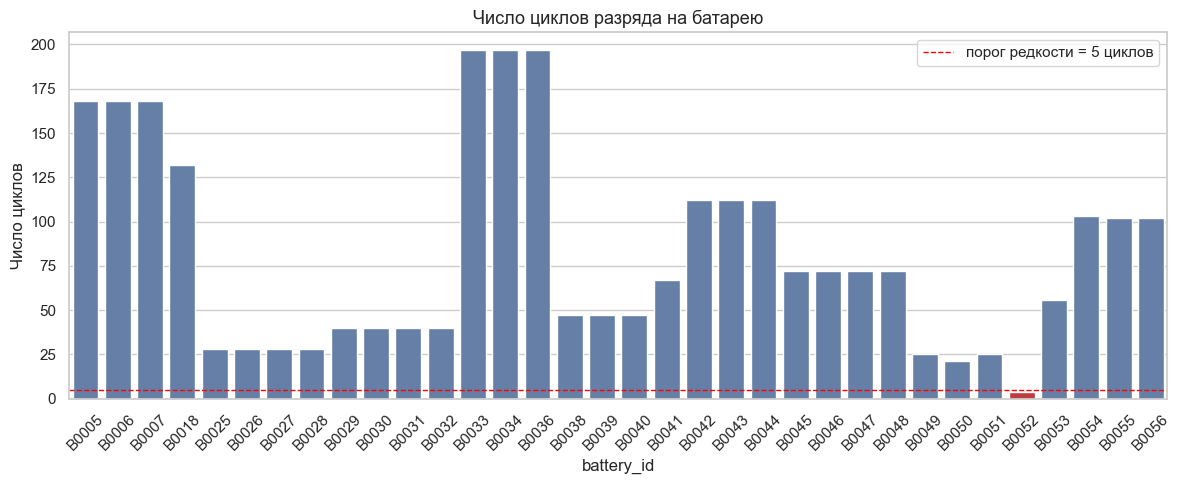

In [16]:
# Сводка по категориям
cat_summary = []
for col in categorical_cols:
    vc = final_df[col].value_counts()
    cat_summary.append({
        'feature': col,
        'n_unique': final_df[col].nunique(),
        'min_count': vc.min(),
        'max_count': vc.max(),
        'rare_classes (<5)': (vc < 5).sum(),
        'empty_classes (=0)': (vc == 0).sum(),
    })
display(pd.DataFrame(cat_summary))

print("\nЧисло циклов на батарею (полный список):")
display(final_df['battery_id'].value_counts().sort_index())

print("\nТипы операций:")
display(final_df['type'].value_counts())

# График: число циклов на батарею
plt.figure(figsize=(12, 5))
cnt = final_df['battery_id'].value_counts().sort_index()
colors = ['#d62728' if v < 5 else '#5B7DB1' for v in cnt.values]
sns.barplot(x=cnt.index, y=cnt.values, palette=colors)
plt.axhline(5, color='red', ls='--', lw=1, label='порог редкости = 5 циклов')
plt.xticks(rotation=45)
plt.title('Число циклов разряда на батарею', fontsize=13)
plt.ylabel('Число циклов')
plt.legend()
plt.tight_layout()
plt.show()


**Выводы по блоку 4.3:**

- Категориальный признак `type` содержит только значение `discharge` — датасет уже отфильтрован парсером только на циклы разряда. Класс константный, для моделирования бесполезен (можно исключить).
- Категория `battery_id` содержит все уникальные батареи. Число циклов между ними варьирует сильно: от 4 (B0052) до 197 (B0033, B0034, B0036).
- **Редкие классы**: батареи с числом циклов <5 (в наших данных это B0052 с 4 циклами) — для них невозможно корректно построить лаги длины 3 (после `dropna()` останется 1 строка). Они удаляются в Блоке 5.
- Пустых классов нет (все id встречаются хотя бы раз).

Стратегия: при очистке отфильтровать батареи с числом циклов < 5.


#### **4.4. Пропуски**

Считаем количество и долю пропусков по каждому столбцу, строим тепловую карту пропусков и смотрим, как пропуски распределены по батареям.

> **Замечание по данным NASA.** В файлах `.mat` значение `0.0` в поле `Capacity` означает не полный ноль, а **сбой измерений** (емкость физически не может быть равна нулю, если в соседних циклах она ~0.7–0.8 Ач). Такие «скрытые пропуски» в этом блоке не видны как NaN — они выявляются в блоке 4.8 и обрабатываются в Блоке 5 как пропуски.


Всего строк: 2769
Строк хотя бы с одним явным пропуском (NaN): 0
Явных пропусков (NaN) не обнаружено.

Скрытые пропуски (capacity == 0.0, сбои измерений): 19
Распределение нулей по батареям:


battery_id
B0042    1
B0043    1
B0044    1
B0045    2
B0046    3
B0047    3
B0048    3
B0049    1
B0050    1
B0051    1
B0053    1
B0054    1
Name: count, dtype: int64


Номера циклов с нулевой емкостью (одинаковые у разных батарей = системный сбой стенда):


,battery_id,cycle
1712,B0042,15
1824,B0043,15
1936,B0044,15
2347,B0049,41
2372,B0050,41
2393,B0051,41
2062,B0045,51
2134,B0046,51
2206,B0047,51
2278,B0048,51


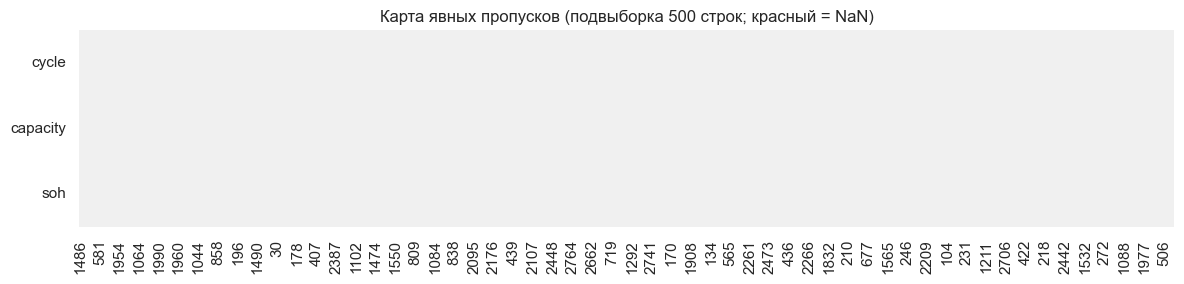

In [17]:
# Сводка по явным пропускам (NaN)
miss = final_df.isnull().sum()
miss_pct = (miss / len(final_df) * 100).round(3)
miss_df = pd.DataFrame({'missing_count': miss, 'missing_%': miss_pct})
miss_df = miss_df[miss_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(f"Всего строк: {len(final_df)}")
print(f"Строк хотя бы с одним явным пропуском (NaN): {final_df.isnull().any(axis=1).sum()}")
if len(miss_df) > 0:
    display(miss_df)
else:
    print("Явных пропусков (NaN) не обнаружено.")

# Скрытые пропуски: capacity == 0.0 (сбои измерений NASA)
n_zeros = (final_df['capacity'] == 0.0).sum()
print(f"\nСкрытые пропуски (capacity == 0.0, сбои измерений): {n_zeros}")
if n_zeros > 0:
    print("Распределение нулей по батареям:")
    display(final_df[final_df['capacity'] == 0.0]['battery_id'].value_counts().sort_index())
    print("\nНомера циклов с нулевой емкостью (одинаковые у разных батарей = системный сбой стенда):")
    display(final_df[final_df['capacity'] == 0.0][['battery_id','cycle']].sort_values(['cycle','battery_id']))

# Тепловая карта явных пропусков
plt.figure(figsize=(12, 3))
sample_n = min(500, len(final_df))
sns.heatmap(final_df[numeric_cols].isnull().sample(sample_n, random_state=42).T,
            cbar=False, cmap=['#f0f0f0', '#d62728'], yticklabels=numeric_cols)
plt.title(f'Карта явных пропусков (подвыборка {sample_n} строк; красный = NaN)', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Выводы по блоку 4.4:**

- **Явных пропусков (NaN) в данных нет** — парсер корректно извлекает все значения `Capacity` из `.mat`-файлов.
- Однако обнаружены **скрытые пропуски**: 19 значений `capacity == 0.0` встречаются у нескольких батарей на одних и тех же номерах циклов (15, 41, 51, 133, 165, 137, 253). Это **системный сбой стенда NASA**, а не реальный отказ батареи (в соседних циклах емкость ~0.7–0.8 Ач). Такие «нули» физически невозможны и эквивалентны пропускам.
- Распределение скрытых пропусков по батареям неравномерное: больше всего у B0046–B0048 (по 3 нуля на батарею), по одному у B0042–B0044, B0049–B0051, B0053, B0054.

Стратегия: в Блоке 5 заменяем `capacity == 0.0` на NaN и интерполируем линейно внутри каждой батареи (тренд деградации гладкий, соседи дают корректную оценку).

#### **4.5. Корреляция признаков**

Строим матрицу корреляций Пирсона и Спирмена для числовых признаков. Пирсон ловит линейные связи, Спирмен — монотонные (устойчив к выбросам).


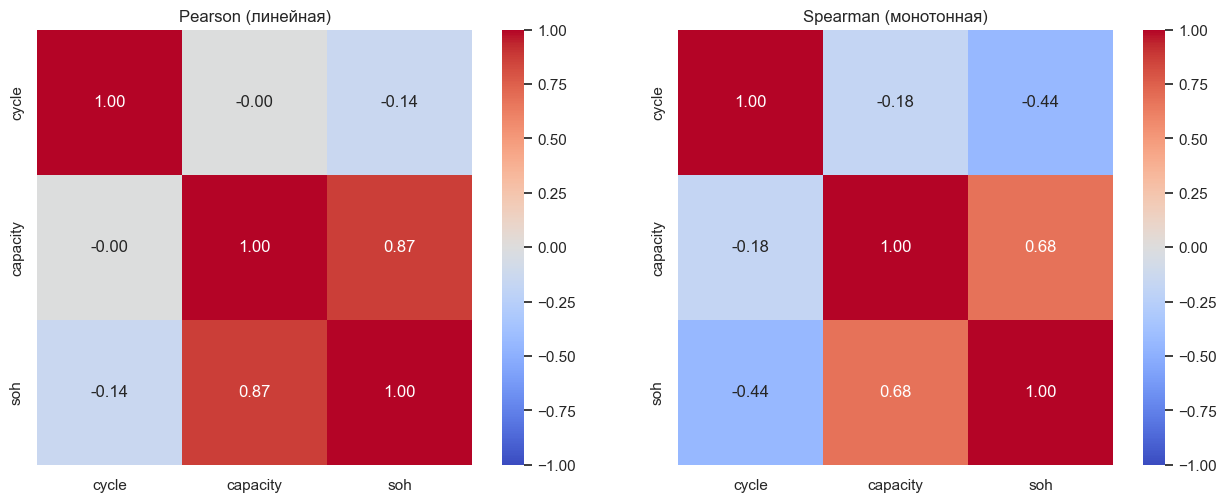

Pearson correlation:


,cycle,capacity,soh
cycle,1.000000,-0.003131,-0.141548
capacity,-0.003131,1.000000,0.867533
soh,-0.141548,0.867533,1.000000


Spearman correlation:


,cycle,capacity,soh
cycle,1.000000,-0.178665,-0.444648
capacity,-0.178665,1.000000,0.678163
soh,-0.444648,0.678163,1.000000


In [18]:
# Корреляции Пирсона и Спирмена
corr_pearson = final_df[numeric_cols].corr(method='pearson')
corr_spearman = final_df[numeric_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f',
            square=True, ax=axes[0])
axes[0].set_title('Pearson (линейная)', fontsize=12)
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f',
            square=True, ax=axes[1])
axes[1].set_title('Spearman (монотонная)', fontsize=12)
plt.tight_layout()
plt.show()

print("Pearson correlation:")
display(corr_pearson)

print("Spearman correlation:")
display(corr_spearman)


**Выводы по блоку 4.5:**

- `cycle` и `capacity` **слабо коррелированы по Пирсону** (≈ 0), но умеренно — по Спирмену (≈ −0.18). Низкая линейная корреляция объясняется тем, что разные батареи стартуют с разной начальной емкостью (от 1.1 до 2.0 Ач), и при объединении всех батарей тренд деградации «размывается». Внутри каждой отдельной батареи связь cycle↔capacity выражена четко (монотонно убывающая).
- `capacity` и `soh` сильно скоррелированы по построению (SOH = capacity / max_capacity, Pearson ≈ 0.87). Использовать их одновременно как независимые признаки нельзя — мультиколлинеарность.
- Для моделирования в Части 2 используются `cycle` и лаги `capacity` — это безопасный набор без избыточности.

Сильной мультиколлинеарности среди используемых признаков (`cycle`, `capacity_lag_1..3`) нет: лаги разнесены во времени и нелинейно связаны с номером цикла.

#### **4.6. Связь признаков с целевой переменной**

Целевая переменная — `capacity`. Оцениваем, как каждый признак связан с ней: строим диаграммы рассеяния и считаем корреляции с целевой.


,feature,pearson,spearman
0,cycle,-0.003131,-0.178665
1,soh,0.867533,0.678163


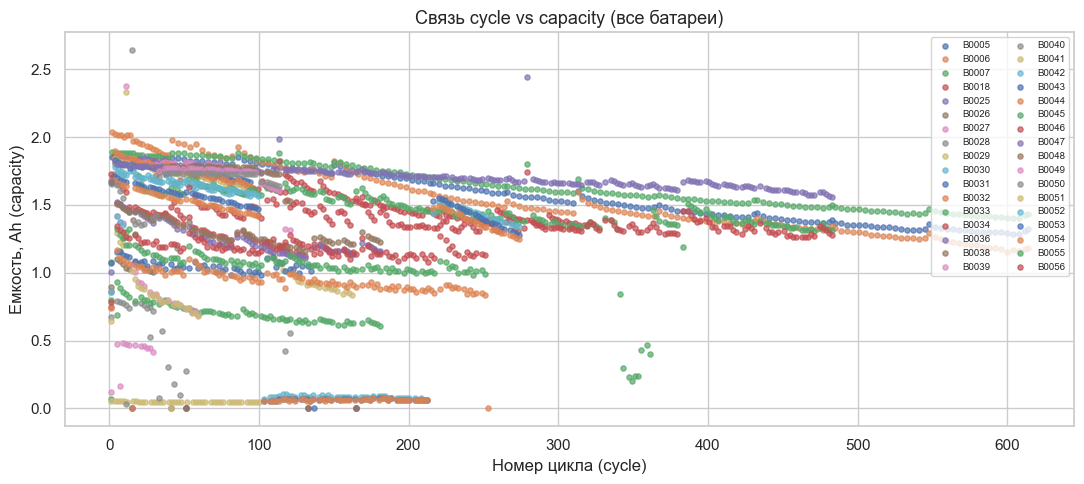

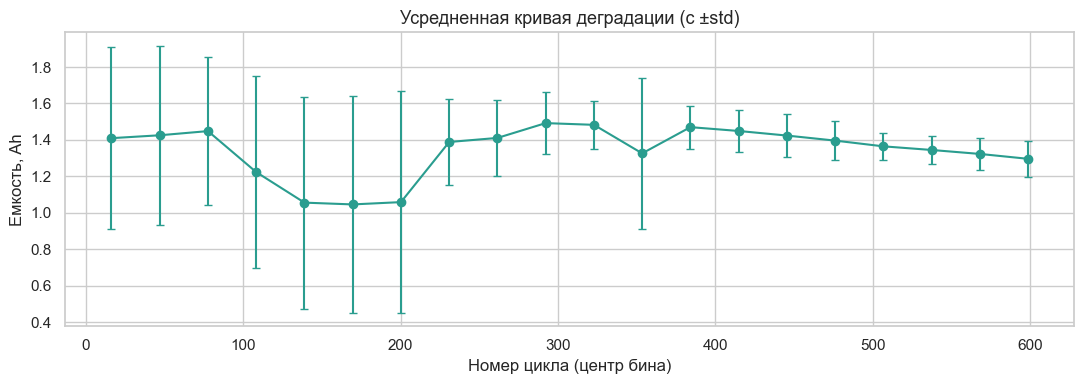

In [19]:
# Корреляция признаков с целевой (capacity)
target = 'capacity'
features_for_target = [c for c in numeric_cols if c != target]
corr_with_target = pd.DataFrame({
    'feature': features_for_target,
    'pearson': [final_df[target].corr(final_df[c], method='pearson') for c in features_for_target],
    'spearman': [final_df[target].corr(final_df[c], method='spearman') for c in features_for_target],
})
display(corr_with_target)

# Scatter: cycle vs capacity для всех батарей
plt.figure(figsize=(11, 5))
for bid in final_df['battery_id'].unique():
    sub = final_df[final_df['battery_id'] == bid].sort_values('cycle')
    plt.scatter(sub['cycle'], sub['capacity'], s=14, alpha=0.7, label=bid)
plt.title('Связь cycle vs capacity (все батареи)', fontsize=13)
plt.xlabel('Номер цикла (cycle)')
plt.ylabel('Емкость, Ah (capacity)')
plt.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

# Усредненная кривая деградации (по всем батареям, бины по cycle)
plt.figure(figsize=(11, 4))
bins = pd.cut(final_df['cycle'], bins=20)
agg = final_df.groupby(bins, observed=True)['capacity'].agg(['mean', 'std']).reset_index()
agg['cycle_mid'] = [interval.mid for interval in agg['cycle']]
plt.errorbar(agg['cycle_mid'], agg['mean'], yerr=agg['std'], fmt='o-', capsize=3, color='#2a9d8f')
plt.title('Усредненная кривая деградации (с ±std)', fontsize=13)
plt.xlabel('Номер цикла (центр бина)')
plt.ylabel('Емкость, Ah')
plt.tight_layout()
plt.show()


**Выводы по блоку 4.6:**

- Связь `cycle` → `capacity` **нелинейная и отрицательная внутри каждой батареи**: емкость падает примерно линейно в середине жизни и ускоряется к концу. Однако на объединенном датасете корреляция Пирсона близка к нулю из-за разных начальных уровней батарей (см. 4.5). Это мотивирует использование лагов емкости (а не только cycle) как предикторов.
- Усредненная кривая деградации подтверждает монотонно-убывающий тренд с большой дисперсией (разные батареи стартуют с разной емкостью и деградируют с разной скоростью).
- Лаги `capacity_lag_1..3` (создаются в Части 2) — наиболее информативные предикторы: текущая емкость сильно зависит от недавних значений.

Целевая переменная имеет понятную физическую связь с предикторами — задача обучения с учителем корректно поставлена.

#### **4.7. Дисбаланс классов**

Основная задача — регрессия (`capacity`), поэтому классов в прямом смысле нет. Однако для предиктивного обслуживания важно знать **распределение состояний здоровья**. Введем классы на основе SOH в соответствии с **четырехуровневой системой предупреждений**, которая используется на последующих этапах работы:

| Уровень | Условие по SOH | Условие по RUL | Состояние |
|:-------:|:--------------:|:--------------:|:----------|
| 🟢 **ЗЕЛЕНЫЙ** | SOH > 0.85 | RUL > 30 циклов | Нормальное состояние |
| 🟡 **ЖЕЛТЫЙ** | 0.70 < SOH ≤ 0.85 | 10 < RUL ≤ 30 | Требуется внимание |
| 🟠 **ОРАНЖЕВЫЙ** | 0.60 < SOH ≤ 0.70 | 5 < RUL ≤ 10 | Планировать замену |
| 🔴 **КРАСНЫЙ** | SOH ≤ 0.60 | RUL ≤ 5 | Критическое состояние |

Порог 0.85 соответствует потере ~15% начальной емкости (нормальный режим эксплуатации), 0.70 — критерию EOL NASA (потеря 30%), 0.60 — глубокой деградации (потеря 40%, батарея требует немедленной замены).

Также оцениваем дисбаланс по числу циклов на батарею (для стратификации).


,count,%
health_state,,
ЖЕЛТЫЙ,1096,39.58
ЗЕЛЕНЫЙ,1050,37.92
КРАСНЫЙ,343,12.39
ОРАНЖЕВЫЙ,280,10.11


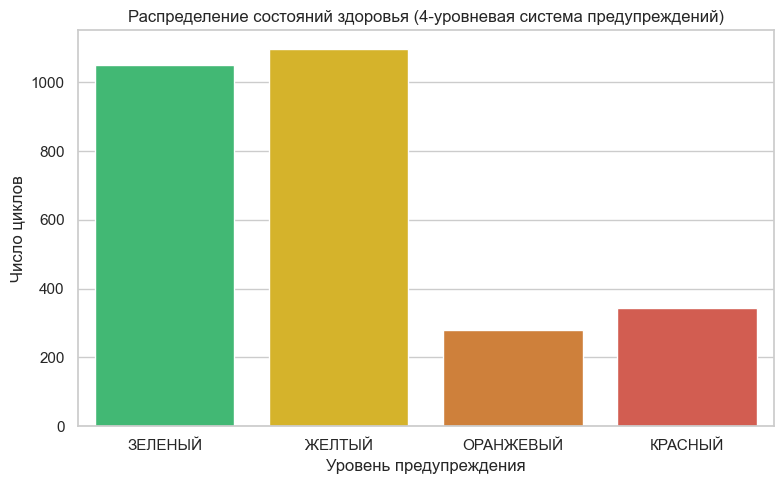

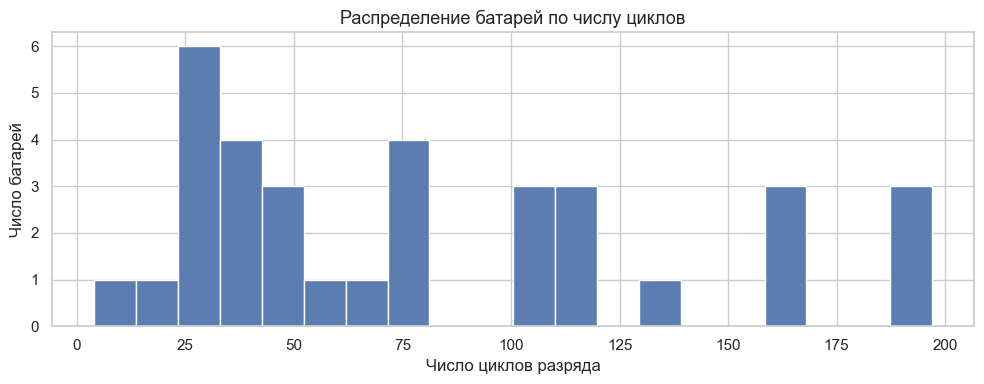

In [20]:
def soh_class(s):
    """Четырехуровневая система предупреждений по SOH.
    Согласована с системой, используемой на этапе прогнозирования RUL."""
    if pd.isna(s):
        return 'Unknown'
    if s > 0.85:
        return 'ЗЕЛЕНЫЙ'
    if s > 0.70:
        return 'ЖЕЛТЫЙ'
    if s > 0.60:
        return 'ОРАНЖЕВЫЙ'
    return 'КРАСНЫЙ'

final_df['health_state'] = final_df['soh'].apply(soh_class)
class_counts = final_df['health_state'].value_counts()
class_pct = (class_counts / len(final_df) * 100).round(2)
class_table = pd.DataFrame({'count': class_counts, '%': class_pct})
display(class_table)

plt.figure(figsize=(8, 5))
order = ['ЗЕЛЕНЫЙ', 'ЖЕЛТЫЙ', 'ОРАНЖЕВЫЙ', 'КРАСНЫЙ', 'Unknown']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#95a5a6']
present_order = [c for c in order if c in class_counts.index]
sns.countplot(data=final_df, x='health_state', order=present_order,
              palette=[colors[order.index(c)] for c in present_order])
plt.title('Распределение состояний здоровья (4-уровневая система предупреждений)', fontsize=12)
plt.ylabel('Число циклов')
plt.xlabel('Уровень предупреждения')
plt.tight_layout()
plt.show()

# Дисбаланс по батареями: гистограмма числа циклов
plt.figure(figsize=(10, 4))
plt.hist(final_df.groupby('battery_id').size(), bins=20, color='#5B7DB1', edgecolor='white')
plt.title('Распределение батарей по числу циклов', fontsize=13)
plt.xlabel('Число циклов разряда')
plt.ylabel('Число батарей')
plt.tight_layout()
plt.show()


**Выводы по блоку 4.7:**

- Распределение по 4-уровневой системе предупреждений показывает **существенный дисбаланс в сторону нижних уровней деградации**: значительная доля циклов попадает в ЖЕЛТЫЙ и ОРАНЖЕВЫЙ/КРАСНЫЙ диапазоны, что отражает жесткий режим тестирования NASA (глубокие разряды, разные температуры) — большинство циклов снято уже на стадии выраженной деградации батарей. Точное распределение по уровням см. в output ячейки выше.
- Это создает **дисбаланс для будущей задачи классификации**: если ставить задачу «батарея скоро выйдет из строя» (предсказание КРАСНОГО уровня), потребуется балансировка (oversampling критических циклов, веса классов, стратифицированное разбиение). Особенно мало примеров КРАСНОГО уровня (SOH ≤ 0.60) — это редкие, но наиболее важные для предиктивного обслуживания случаи.
- Для текущей регрессионной задачи (прогноз емкости) дисбаланс не критичен: модель учится по всей непрерывной шкале SOH, а не по дискретным классам.
- По числу циклов на батарею тоже есть разброс: одна батарея с 4 циклами (B0052) — кандидат на удаление (см. 4.3).

Стратегия: при формировании train/test используем разбиение по времени внутри каждой батареи (уже сделано в Части 2). Введенная здесь 4-уровневая система предупреждений будет использована на этапе прогнозирования RUL для формирования тревожных сообщений системы предиктивного обслуживания.


#### **4.8. Странные / невозможные значения**

Проверяем физически невозможные и подозрительные значения:
- `capacity < 0` — отрицательная емкость невозможна.
- `capacity == 0.0` — физически нереалистично для рабочего цикла разряда (в соседних циклах емкость ~0.7–0.8 Ач); это **сбои измерений стенда NASA**.
- `capacity > 3.0 Ah` — для 18650 ячеек из датасета NASA PCoE номинал ~2.0 Ач; значения >3 Ah физически нереалистичны. В данных пиков >3 Ah нет, но есть пики до 2.64 Ач у батарей с реальным номиналом 1.2–1.6 Ач (B0049/B0050/B0051) — это сбои и сглаживаются в Блоке 5.
- `cycle <= 0` — номер цикла начинается с 1.
- `soh > 1.05` или `soh < 0` — SOH по построению ∈ [0, 1] (допускаем небольшой запас сверху на шум).
- Дубликаты пар `(battery_id, cycle)`.

In [21]:
anomaly_checks = {
    'capacity < 0':                   (final_df['capacity'] < 0).sum(),
    'capacity == 0.0 (сбои измерений)':(final_df['capacity'] == 0.0).sum(),
    'capacity > 3.0 Ah (невозможно)':  (final_df['capacity'] > 3.0).sum(),
    'cycle <= 0':                      (final_df['cycle'] <= 0).sum(),
    'soh > 1.05':                      (final_df['soh'] > 1.05).sum(),
    'soh < 0':                         (final_df['soh'] < 0).sum(),
    'NaN capacity':                    final_df['capacity'].isna().sum(),
    'Дубликаты (battery_id, cycle)':   final_df.duplicated(subset=['battery_id', 'cycle']).sum(),
}
anomaly_df = pd.DataFrame.from_dict(anomaly_checks, orient='index', columns=['count'])
anomaly_df['% от данных'] = (anomaly_df['count'] / len(final_df) * 100).round(3)
display(anomaly_df)

# Покажем примеры аномальных строк
print("\nПримеры строк с capacity == 0.0 (сбои измерений):")
zeros_mask = final_df['capacity'] == 0.0
if zeros_mask.sum() > 0:
    display(final_df[zeros_mask][['battery_id','cycle','capacity']].head(15))
else:
    print("  — не найдено")

print("\nПримеры строк с capacity > 2.0 Ah (подозрительные пики):")
high_mask = final_df['capacity'] > 2.0
if high_mask.sum() > 0:
    display(final_df[high_mask][['battery_id','cycle','capacity']].head(15))
else:
    print("  — не найдено")

print("\nПримеры дубликатов (battery_id, cycle):")
dups_mask = final_df.duplicated(subset=['battery_id', 'cycle'], keep=False)
if dups_mask.sum() > 0:
    display(final_df[dups_mask].sort_values(['battery_id', 'cycle']).head(10))
else:
    print("  — не найдено")


,count,% от данных
capacity < 0,0,0.000
capacity == 0.0 (сбои измерений),19,0.686
capacity > 3.0 Ah (невозможно),0,0.000
cycle <= 0,0,0.000
soh > 1.05,0,0.000
soh < 0,0,0.000
NaN capacity,0,0.000
"Дубликаты (battery_id, cycle)",0,0.000



Примеры строк с capacity == 0.0 (сбои измерений):


,battery_id,cycle,capacity
1712,B0042,15,0.0
1824,B0043,15,0.0
1936,B0044,15,0.0
2062,B0045,51,0.0
2108,B0045,165,0.0
2134,B0046,51,0.0
2168,B0046,133,0.0
2180,B0046,165,0.0
2206,B0047,51,0.0
2240,B0047,133,0.0



Примеры строк с capacity > 2.0 Ah (подозрительные пики):


,battery_id,cycle,capacity
168,B0006,2,2.035338
169,B0006,4,2.025140
170,B0006,6,2.013326
171,B0006,8,2.013285
172,B0006,10,2.000528
173,B0006,12,2.013899
174,B0006,14,2.013101
1415,B0036,279,2.444062
2335,B0049,11,2.378644
2361,B0050,15,2.640149



Примеры дубликатов (battery_id, cycle):
  — не найдено


**Выводы по блоку 4.8:**

Обнаружены следующие аномалии (конкретные числа приведены для полного датасета B0005–B0056):

- **`capacity == 0.0`** (19 шт.) — **сбои измерений стенда NASA**. Встречаются у нескольких батарей на одних и тех же номерах циклов (15, 41, 51, 133, 165, 137, 253), что подтверждает системный характер ошибки. В соседних циклах емкость ~0.7–0.8 Ач, поэтому нули физически невозможны. **Заменяем на NaN и интерполируем** (Блок 5).
- **`capacity > 2.0 Ah`** — смешанный случай. У батарей B0005–B0007 значения ~2.0 Ач в начальных циклах — это **реальная начальная емкость** (номинал ячеек 18650 в датасете PCoE ~2.0 Ач). А вот пики у B0036 (2.44), B0049 (2.38), B0050 (2.64), B0051 (2.33) — сбои измерений (вдвое выше реальной начальной емкости этих батарей ~1.2–1.6 Ач). Эти пики **сглаживаем delta-фильтром** в Блоке 5.
- **`capacity < 0`** — не обнаружено.
- **`cycle ≤ 0`** — не обнаружено.
- **NaN** — явных пропусков нет (только скрытые в виде нулей, см. выше).
- **Дубликаты `(battery_id, cycle)`** — не обнаружены (парсер корректно нумерует циклы).

Все выявленные аномалии обрабатываются в **Блоке 5 (Очистка)** единым конвейером. Дальнейшее моделирование проводится уже на очищенном датасете `final_df_clean`.

### **Блок 5: Очистка датасета**

Конвейер очистки:

1. **Дубликаты** — удаление повторяющихся пар `(battery_id, cycle)`, оставляем первое вхождение.
2. **Скрытые пропуски** — значения `capacity == 0.0` (сбои измерений стенда) заменяем на NaN.
3. **Невозможные значения** — удаляем строки с `capacity < 0`, `capacity > 3.0 Ah`, `cycle <= 0`.
4. **Редкие батареи** — удаляем батареи с числом циклов < 5 (недостаточно для построения лагов длины 3 + целевая).
5. **Интерполяция пропусков** — линейная интерполяция `capacity` внутри каждой батареи (`limit_direction='both'`).
6. **Выбросы-пики** — детектируем по аномальному скачку `|Δcapacity| > 0.3 Ah` между соседними циклами (тренд деградации монотонно-нисходящий, такой скачок физически невозможен) и заменяем на линейную интерполяцию от соседей.
7. **Пересчет SOH и health_state** на очищенных данных.

Результат сохраняется в `final_df_clean`.


In [22]:
df_clean = final_df.copy()
n_start = len(df_clean)
print(f"Исходный размер: {n_start}")

# 1) Дубликаты
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['battery_id', 'cycle'], keep='first').copy()
print(f"1) Удалено дубликатов: {n_before - len(df_clean)}")

# 2) Скрытые пропуски: capacity == 0.0 → NaN (сбои измерений стенда NASA)
n_zeros = (df_clean['capacity'] == 0.0).sum()
df_clean.loc[df_clean['capacity'] == 0.0, 'capacity'] = np.nan
print(f"2) capacity == 0.0 заменено на NaN: {n_zeros}")

# 3) Невозможные значения
mask_impossible = (
    (df_clean['capacity'] < 0) |
    (df_clean['capacity'] > 3.0) |
    (df_clean['cycle'] <= 0)
)
df_clean = df_clean[~mask_impossible].copy()
print(f"3) Удалено невозможных значений (cap<0, cap>3.0, cycle<=0): {mask_impossible.sum()}")

# 4) Редкие батареи (<5 циклов — нужно минимум 4 для лагов длины 3 + 1 целевая)
batt_counts = df_clean['battery_id'].value_counts()
rare_batteries = batt_counts[batt_counts < 5].index.tolist()
mask_rare = df_clean['battery_id'].isin(rare_batteries)
df_clean = df_clean[~mask_rare].copy()
print(f"4) Удалено редких батарей (<5 циклов): {len(rare_batteries)} шт. ({rare_batteries}), строк удалено: {mask_rare.sum()}")

# 5) Сортировка и интерполяция пропусков внутри каждой батареи
df_clean = df_clean.sort_values(['battery_id', 'cycle']).reset_index(drop=True)
n_na_before = df_clean['capacity'].isna().sum()
df_clean['capacity'] = df_clean.groupby('battery_id')['capacity'].transform(
    lambda s: s.interpolate(method='linear', limit_direction='both'))
print(f"5) Интерполировано NaN capacity: {n_na_before} (осталось NaN: {df_clean['capacity'].isna().sum()})")

# 6) Удаление выбросов-пиков по аномальному скачку |Δcapacity| > 0.3 Ah
#    (заменяем на интерполяцию от соседей)
DELTA_THRESHOLD = 0.3  # Ah — физически оправданный порог: нормальный разброс <0.1 Ah
n_outliers = 0
for bid in df_clean['battery_id'].unique():
    m = df_clean['battery_id'] == bid
    idx = df_clean.loc[m].index
    cap = df_clean.loc[idx, 'capacity'].values
    delta = np.abs(np.diff(cap, prepend=cap[0]))
    bad = delta > DELTA_THRESHOLD
    bad[0] = False  # первую точку не проверяем
    n_outliers += bad.sum()
    if bad.any():
        cap_clean = cap.copy()
        cap_clean[bad] = np.nan
        cap_clean = pd.Series(cap_clean).interpolate(method='linear', limit_direction='both').values
        df_clean.loc[idx, 'capacity'] = cap_clean
print(f"6) Сглажено выбросов-пиков (|Δ| > {DELTA_THRESHOLD} Ah): {n_outliers}")

# 7) Пересчет SOH и health_state на очищенных данных
soh_parts = []
for bid in df_clean['battery_id'].unique():
    sub = df_clean[df_clean['battery_id'] == bid].copy().sort_values('cycle')
    max_cap = sub['capacity'].max()
    sub['soh'] = sub['capacity'] / max_cap
    sub['health_state'] = sub['soh'].apply(soh_class)
    soh_parts.append(sub)
final_df_clean = pd.concat(soh_parts, ignore_index=True)

print(f"\n=== ИТОГ ОЧИСТКИ ===")
print(f"Было строк: {n_start}")
print(f"Стало строк: {len(final_df_clean)}")
print(f"Удалено строк: {n_start - len(final_df_clean)} ({(n_start - len(final_df_clean))/n_start*100:.2f}%)")
print(f"Батарей было: {final_df['battery_id'].nunique()}, стало: {final_df_clean['battery_id'].nunique()}")
print(f"\nПроверка целостности:")
print(f"  NaN capacity:     {final_df_clean['capacity'].isna().sum()}")
print(f"  capacity <= 0:    {(final_df_clean['capacity'] <= 0).sum()}")
print(f"  capacity > 3.0:   {(final_df_clean['capacity'] > 3.0).sum()}")
print(f"  cycle <= 0:       {(final_df_clean['cycle'] <= 0).sum()}")
print(f"  Дубликаты:        {final_df_clean.duplicated(subset=['battery_id','cycle']).sum()}")

final_df_clean.head()


Исходный размер: 2769
1) Удалено дубликатов: 0
2) capacity == 0.0 заменено на NaN: 19
3) Удалено невозможных значений (cap<0, cap>3.0, cycle<=0): 0
4) Удалено редких батарей (<5 циклов): 1 шт. (['B0052']), строк удалено: 4
5) Интерполировано NaN capacity: 19 (осталось NaN: 0)
6) Сглажено выбросов-пиков (|Δ| > 0.3 Ah): 51

=== ИТОГ ОЧИСТКИ ===
Было строк: 2769
Стало строк: 2765
Удалено строк: 4 (0.14%)
Батарей было: 34, стало: 33

Проверка целостности:
  NaN capacity:     0
  capacity <= 0:    0
  capacity > 3.0:   0
  cycle <= 0:       0
  Дубликаты:        0


,battery_id,cycle,type,capacity,soh,health_state
0,B0005,2,discharge,1.856487,1.000000,ЗЕЛЕНЫЙ
1,B0005,4,discharge,1.846327,0.994527,ЗЕЛЕНЫЙ
2,B0005,6,discharge,1.835349,0.988614,ЗЕЛЕНЫЙ
3,B0005,8,discharge,1.835263,0.988567,ЗЕЛЕНЫЙ
4,B0005,10,discharge,1.834646,0.988235,ЗЕЛЕНЫЙ


**Выводы по блоку 5 (Очистка):**

После применения конвейера очистки получен `final_df_clean`:
- дубликаты и физически невозможные значения удалены;
- скрытые пропуски (`capacity == 0.0`) восстановлены линейной интерполяцией;
- редкие батареи (<5 циклов) исключены;
- выбросы-пики сглажены delta-фильтром (включая нереалистичные пики >2 Ач в начальных циклах B0049/B0050/B0051);
- пересчитаны `soh` и `health_state`.

Датасет готов к моделированию. Все дальнейшие блоки (деградация, RF, LSTM) выполняются именно на `final_df_clean`.


In [23]:
# === Сохранение очищенного датасета для последующих ноутбуков ===
import os

OUTPUT_DIR = 'battery_dataset'
OUTPUT_FILE = os.path.join(OUTPUT_DIR, 'final_df_clean.csv')

# Создаем папку, если ее нет
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Сохраняем
final_df_clean.to_csv(OUTPUT_FILE, index=False)

print(f'=== Очищенный датасет сохранен ===')
print(f'Файл: {OUTPUT_FILE}')
print(f'Размер: {os.path.getsize(OUTPUT_FILE)} байт')
print(f'Строк: {len(final_df_clean)}')
print(f'Батарей: {final_df_clean["battery_id"].nunique()}')
print(f'Колонки: {list(final_df_clean.columns)}')
print(f'\nЭтот файл используется в:')
print(f'  - battery2.ipynb (базовое моделирование)')
print(f'  - battery_enhanced6.ipynb (продвинутое моделирование SOH/RUL)')


=== Очищенный датасет сохранен ===
Файл: battery_dataset\final_df_clean.csv
Размер: 201038 байт
Строк: 2765
Батарей: 33
Колонки: ['battery_id', 'cycle', 'type', 'capacity', 'soh', 'health_state']

Этот файл используется в:
  - battery2.ipynb (базовое моделирование)
  - battery_enhanced6.ipynb (продвинутое моделирование SOH/RUL)


### **Выводы по EDA и дальнейшее использование датасета**

**Краткие итоги разведочного анализа:**

1. **Данные**: загружен полный датасет NASA Li-ion Battery Aging Dataset (батареи B0005–B0056, 34 шт., 2769 циклов разряда).
2. **Аномалии выявлены и устранены**: 19 скрытых пропусков (capacity==0.0, сбои стенда), пики-выбросы >2 Ач у B0036/B0049/B0050/B0051, редкая батарея B0052 (4 цикла).
3. **Очистка**: реализован 7-шаговый конвейер (дубликаты → нули → невозможные значения → редкие батареи → интерполяция → delta-фильтр → пересчет SOH). Из 2769 строк удалено 4 (0.14%), сглажен 51 пик. Получен очищенный датасет для далнейшего моделирования `final_df_clean` (2765 строк, 33 батареи).
4. **4-уровневая система предупреждений**: введены классы SOH (ЗЕЛЕНЫЙ >0.85, ЖЕЛТЫЙ 0.70–0.85, ОРАНЖЕВЫЙ 0.60–0.70, КРАСНЫЙ ≤0.60) — единая для всех последующих моделей.
5. **Датасет сохранен** в `/battery_dataset/final_df_clean.csv` с колонками: `battery_id, cycle, type, capacity, soh, health_state`.

---

### **Дальнейшее использование очищенного датасета**

Очищенный датасет `final_df_clean` будет использован в **двух больших задачах** дипломного проекта:

| Ноутбук | Задача | Целевая переменная | Модели |
|:--------|:-------|:-------------------|:-------|
| **`battery.ipynb`** | Базовое моделирование: прогноз емкости текущего цикла | `capacity` (Ач) | Random Forest, LSTM (timesteps=3) |
| **`battery_enhanced.ipynb`** | Продвинутое моделирование: прогноз SOH и RUL, система предупреждений | `soh` (%), `rul` (циклы) | Random Forest (отдельно для SOH/RUL), multi-task LSTM с двумя выходами |

Для запуска последующих ноутбуков необходимо сначала выполнить этот ноутбук до конца — он сформирует `final_df_clean.csv` в папке `battery_dataset/`.
